In [14]:
import pandas as pd

# Chargement du dataset
df = pd.read_csv("data/bank-additional-full.csv", sep=';')

# Aperçu
print("Dimensions du dataset :", df.shape)
df.head()


Dimensions du dataset : (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [15]:
# Vérification des types de variables
df.info()

# Statistiques globales des variables numériques
df.describe()


# Valeurs uniques par variable
df.nunique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

In [16]:
# Vérification des "unknown"
for col in df.columns:
    if df[col].dtype == 'object':
        if 'unknown' in df[col].unique():
            print(f"{col} contient des valeurs 'unknown'")


job contient des valeurs 'unknown'
marital contient des valeurs 'unknown'
education contient des valeurs 'unknown'
default contient des valeurs 'unknown'
housing contient des valeurs 'unknown'
loan contient des valeurs 'unknown'


In [17]:
# Colonnes concernées
cols_to_fix = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# Remplacer 'unknown' par la valeur la plus fréquente de chaque colonne
for col in cols_to_fix:
    mode = df[col].mode()[0]
    df[col] = df[col].replace('unknown', mode)

# Vérification après nettoyage
for col in cols_to_fix:
    print(f"{col} : 'unknown' encore présent ? {'unknown' in df[col].unique()}")


job : 'unknown' encore présent ? False
marital : 'unknown' encore présent ? False
education : 'unknown' encore présent ? False
default : 'unknown' encore présent ? False
housing : 'unknown' encore présent ? False
loan : 'unknown' encore présent ? False


In [18]:
# Nombre de doublons
print("Doublons détectés :", df.duplicated().sum())

# Supprimer les doublons s'il y en a
df = df.drop_duplicates()


Doublons détectés : 14


In [19]:
# Sauvegarder le DataFrame nettoyé
df.to_csv("data/bank_cleaned.csv", index=False)

print("✅ Dataset nettoyé sauvegardé sous : data/bank_cleaned.csv")


✅ Dataset nettoyé sauvegardé sous : data/bank_cleaned.csv


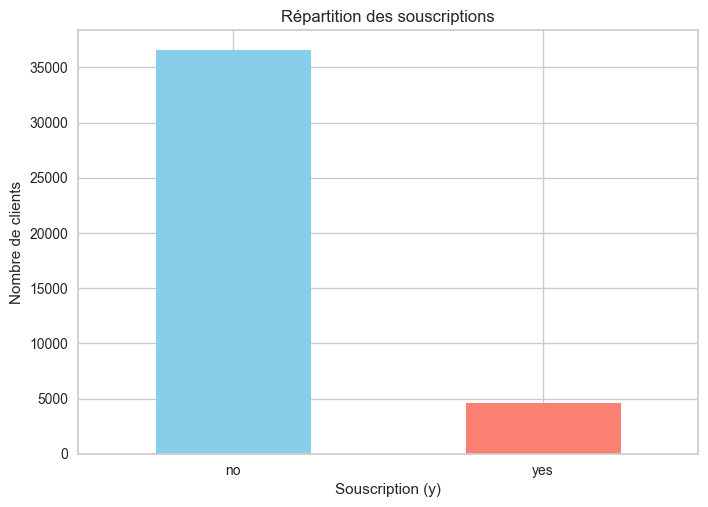

In [20]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Répartition des souscriptions')
plt.xlabel('Souscription (y)')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=0)
plt.show()


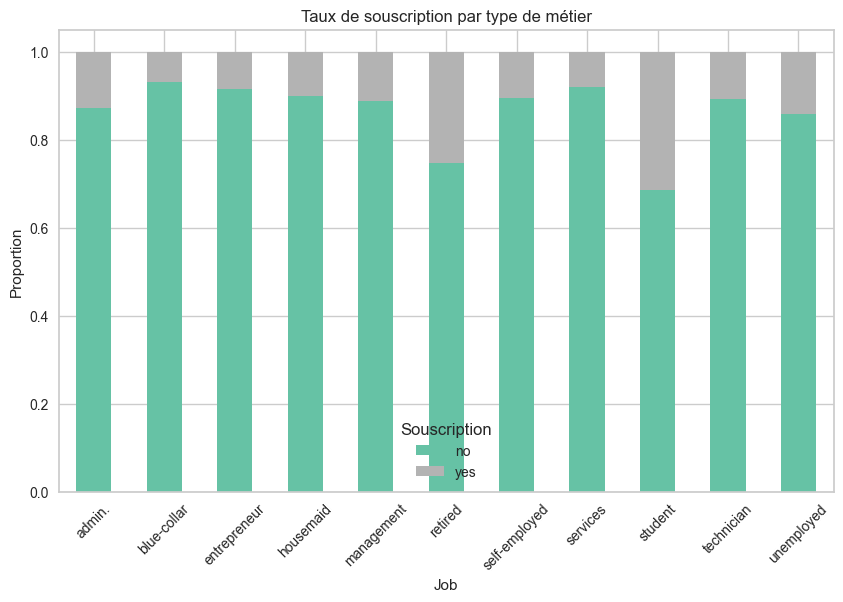

In [35]:
import seaborn as sns
import pandas as pd

job_subscription = pd.crosstab(df['job'], df['y'], normalize='index')

job_subscription.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title('Taux de souscription par type de métier')
plt.xlabel('Job')
plt.ylabel('Proportion')
plt.legend(title='Souscription')
plt.xticks(rotation=45)
plt.show()


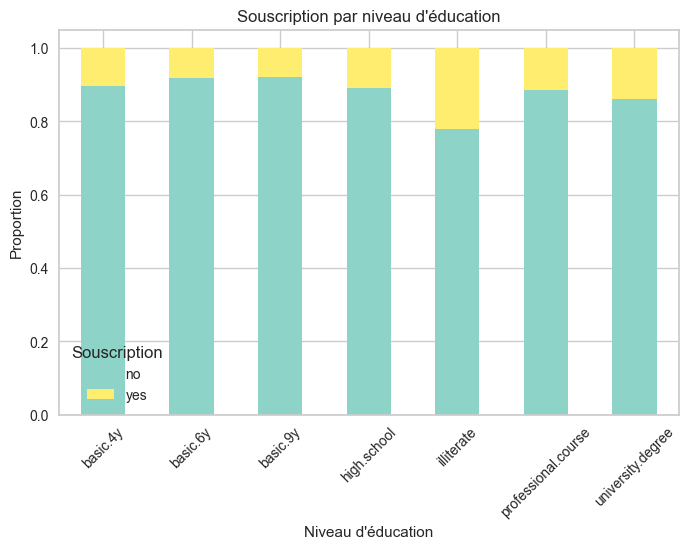

In [22]:
edu_subscription = pd.crosstab(df['education'], df['y'], normalize='index')

edu_subscription.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set3')
plt.title('Souscription par niveau d\'éducation')
plt.xlabel('Niveau d\'éducation')
plt.ylabel('Proportion')
plt.legend(title='Souscription')
plt.xticks(rotation=45)
plt.show()


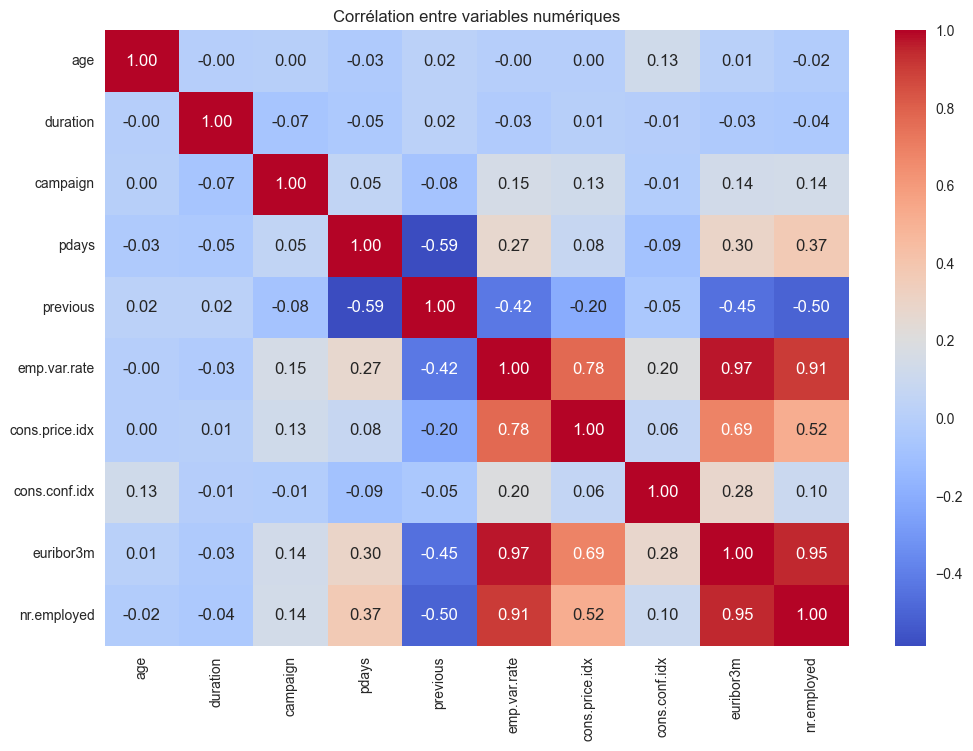

In [36]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Corrélation entre variables numériques")
plt.show()


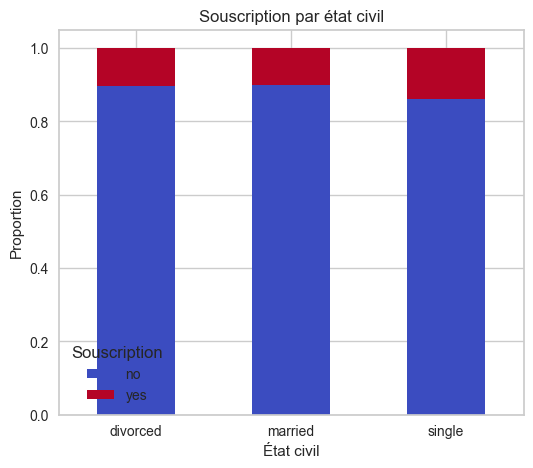

In [24]:
marital_subscription = pd.crosstab(df['marital'], df['y'], normalize='index')
marital_subscription.plot(kind='bar', stacked=True, figsize=(6,5), colormap='coolwarm')
plt.title('Souscription par état civil')
plt.xlabel('État civil')
plt.ylabel('Proportion')
plt.legend(title='Souscription')
plt.xticks(rotation=0)
plt.show()


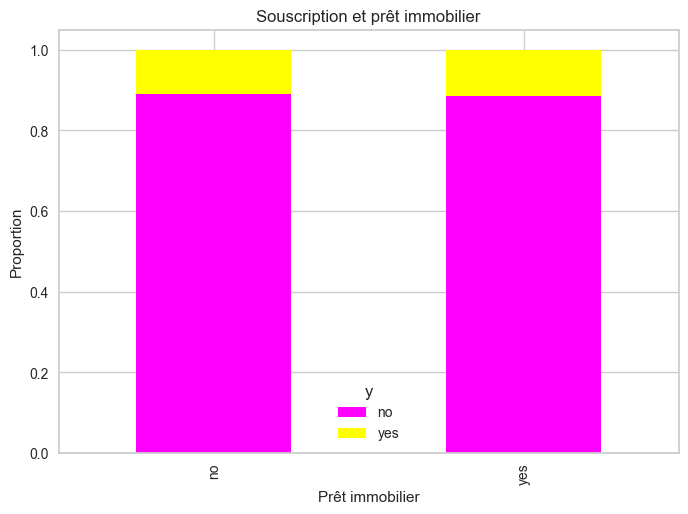

In [25]:
housing_subscription = pd.crosstab(df['housing'], df['y'], normalize='index')
housing_subscription.plot(kind='bar', stacked=True, colormap='spring')
plt.title('Souscription et prêt immobilier')
plt.xlabel('Prêt immobilier')
plt.ylabel('Proportion')
plt.show()


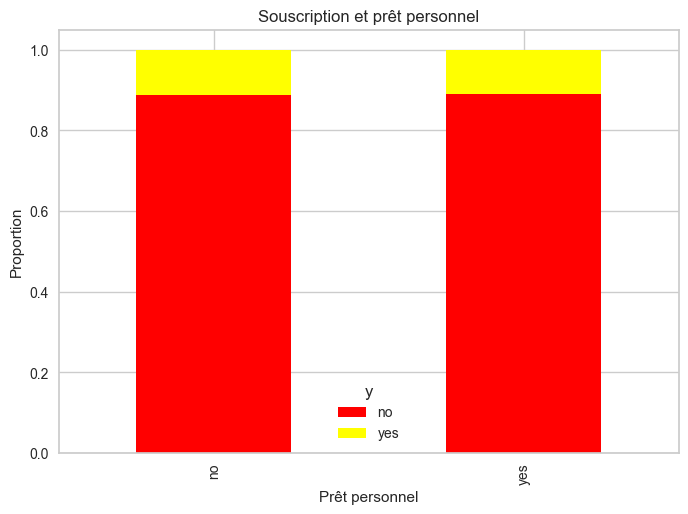

In [26]:
loan_subscription = pd.crosstab(df['loan'], df['y'], normalize='index')
loan_subscription.plot(kind='bar', stacked=True, colormap='autumn')
plt.title('Souscription et prêt personnel')
plt.xlabel('Prêt personnel')
plt.ylabel('Proportion')
plt.show()


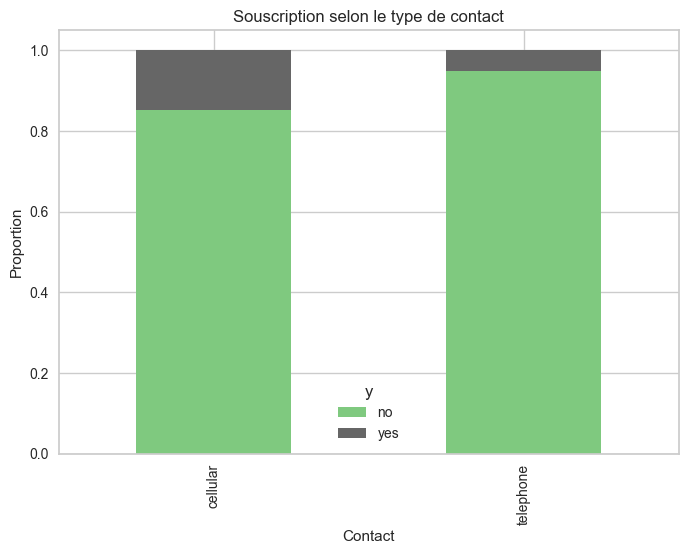

In [27]:
contact_subscription = pd.crosstab(df['contact'], df['y'], normalize='index')
contact_subscription.plot(kind='bar', stacked=True, colormap='Accent')
plt.title('Souscription selon le type de contact')
plt.xlabel('Contact')
plt.ylabel('Proportion')
plt.show()



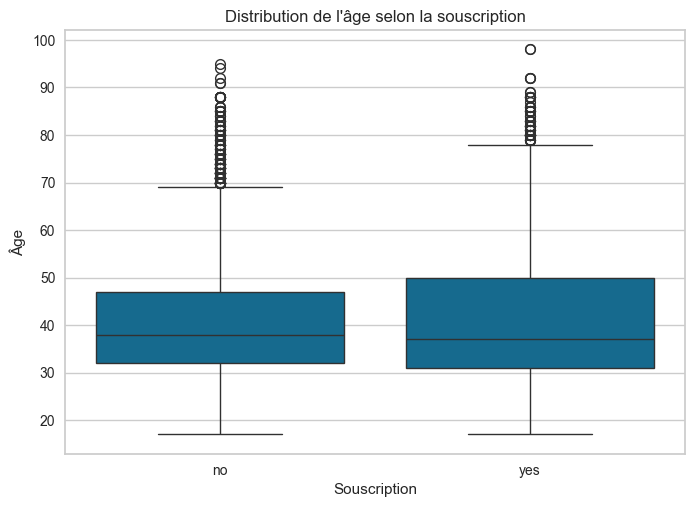

In [37]:
sns.boxplot(x='y', y='age', data=df)
plt.title("Distribution de l'âge selon la souscription")
plt.xlabel("Souscription")
plt.ylabel("Âge")
plt.show()


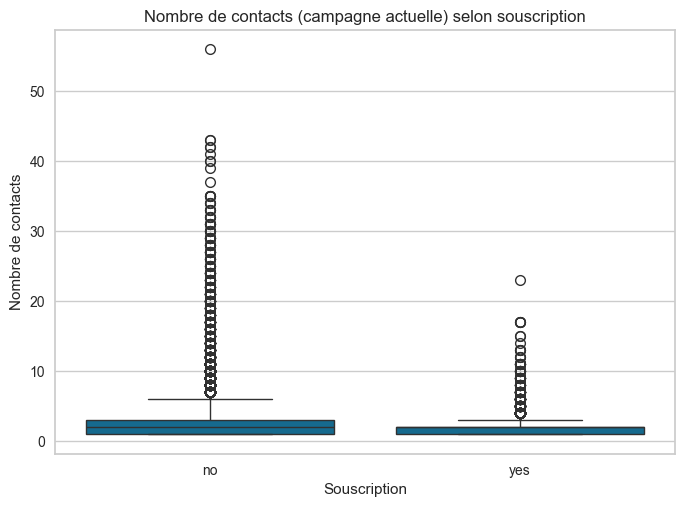

In [38]:
sns.boxplot(x='y', y='campaign', data=df)
plt.title("Nombre de contacts (campagne actuelle) selon souscription")
plt.xlabel("Souscription")
plt.ylabel("Nombre de contacts")
plt.show()


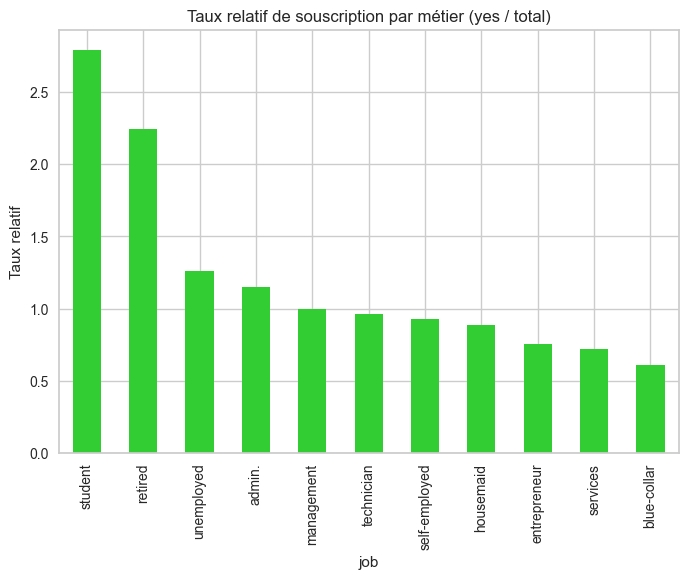

In [30]:
job_yes = df[df['y'] == 'yes']['job'].value_counts(normalize=True)
job_total = df['job'].value_counts(normalize=True)
job_ratio = (job_yes / job_total).sort_values(ascending=False)

job_ratio.plot(kind='bar', color='limegreen')
plt.title("Taux relatif de souscription par métier (yes / total)")
plt.ylabel("Taux relatif")
plt.show()


In [31]:
# Import des bibliothèques
import pandas as pd
from pycaret.classification import *

# Charger le dataset nettoyé
df = pd.read_csv("data/bank_cleaned.csv")

# Vérifier la forme du dataset
print("✅ Dataset chargé avec succès :", df.shape)
df.head()



✅ Dataset chargé avec succès : (41174, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [40]:
!pip install seaborn


In [41]:
# Configuration PyCaret
clf = setup(
    data=df,
    target='y',
    session_id=123  # reproductibilité
)


print("✅ Environnement PyCaret configuré avec succès !")


,Description,Value
0,Session id,123
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(41174, 21)"
5,Transformed data shape,"(41174, 54)"
6,Transformed train set shape,"(28821, 54)"
7,Transformed test set shape,"(12353, 54)"
8,Numeric features,10
9,Categorical features,10


✅ Environnement PyCaret configuré avec succès !


In [46]:
# Comparer tous les modèles et afficher le meilleur
best_model = compare_models()


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9160,0.9464,0.9160,0.9092,0.9114,0.5353,0.5405,2.4860
lightgbm,Light Gradient Boosting Machine,0.9153,0.9494,0.9153,0.9096,0.9117,0.5414,0.5446,0.8690
rf,Random Forest Classifier,0.9126,0.9397,0.9126,0.9035,0.9059,0.4989,0.5081,1.4490
lr,Logistic Regression,0.9104,0.9317,0.9104,0.8993,0.9012,0.4646,0.4803,2.7980
ada,Ada Boost Classifier,0.9095,0.9377,0.9095,0.8980,0.8998,0.4561,0.4726,1.1370
lda,Linear Discriminant Analysis,0.9092,0.9327,0.9092,0.9026,0.9051,0.5061,0.5096,0.5040
ridge,Ridge Classifier,0.9075,0.9327,0.9075,0.8939,0.8926,0.4004,0.4334,0.3850
knn,K Neighbors Classifier,0.9048,0.8727,0.9048,0.8971,0.9000,0.4776,0.4815,0.9740
et,Extra Trees Classifier,0.9030,0.9179,0.9030,0.8892,0.8922,0.4130,0.4292,1.8500
svm,SVM - Linear Kernel,0.8992,0.9143,0.8992,0.8921,0.8848,0.3715,0.4060,1.0270


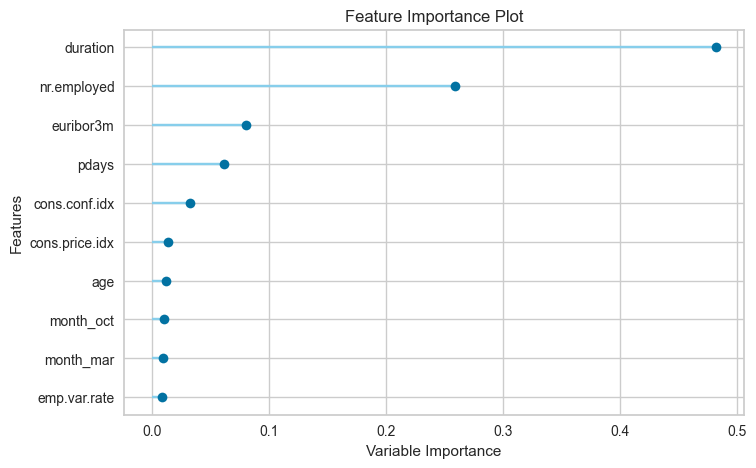

In [48]:
# Importance des variables
plot_model(best_model, plot='feature')

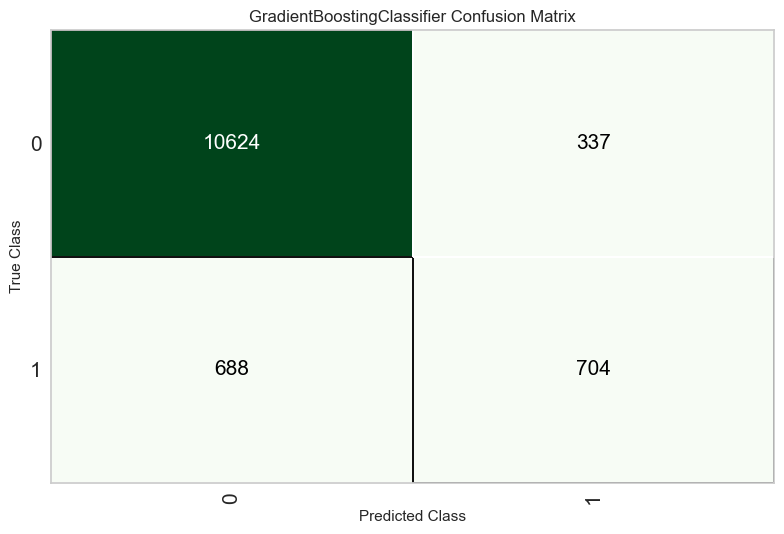

In [50]:
# Matrice de confusion
plot_model(best_model, plot='confusion_matrix')


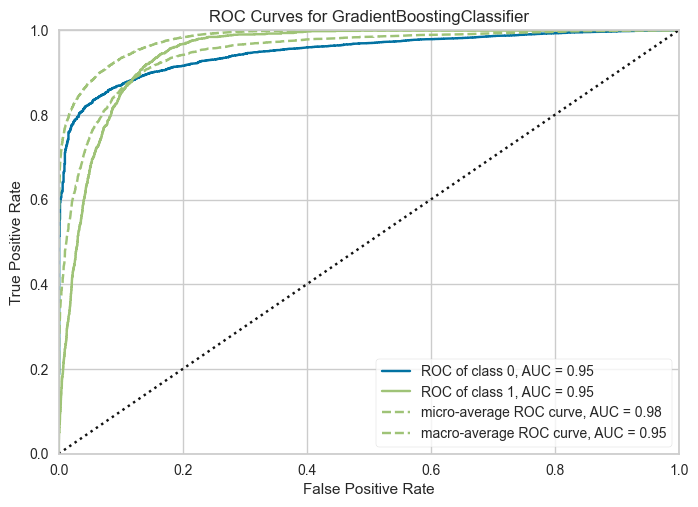

In [52]:
# Courbe ROC
plot_model(best_model, plot='auc')


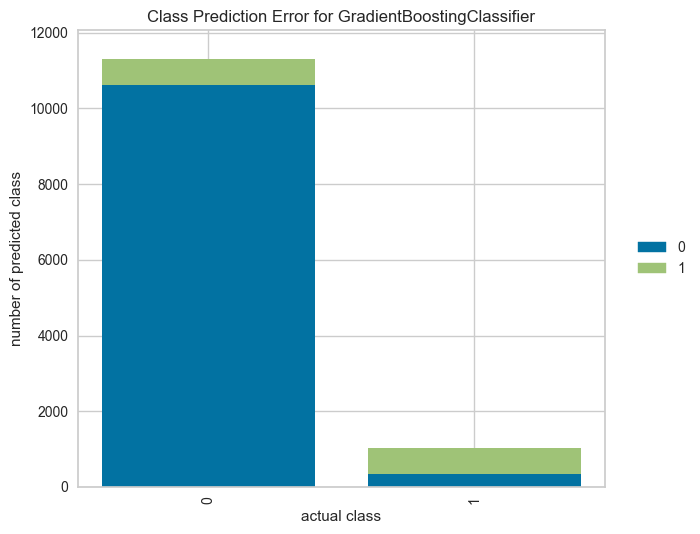

In [54]:
# Erreurs
plot_model(best_model, plot='error')


In [55]:
# Sauvegarder le modèle entraîné
save_model(best_model, 'bank_marketing_best_model')


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['age', 'duration', 'campaign',
                                              'pdays', 'previous',
                                              'emp.var.rate', 'cons.price.idx',
                                              'cons.conf.idx', 'euribor3m',
                                              'nr.employed'],
                                     transformer=Simple...
                                             criterion='friedman_mse', init=None,
                                             learning_rate=0.1, loss='log_loss',
                                             max_depth=3, max_features=None,
                   